Sistema Inteligente Baseado em
Lógica Fuzzy para Gerenciamento
de Cargas Prioritárias
em Situações de Emergência

Autores:

Sara Carolina
Luigi Antônio

CEFET-MG

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dados = {
    'carga': [
        'Data Center',
        'Sistema de Incêndio',
        'CLP Linha de Produção',
        'Iluminação de Emergência',
        'Bomba de Refrigeração',
        'Compressor Industrial',
        'Ar-condicionado Administrativo',
        'Tomadas Administrativas',
        'Iluminação Comum',
        'Máquina Auxiliar'
    ],
    'potencia_kw': [8, 5, 4, 2, 12, 18, 10, 6, 4, 15],
    'criticidade': [10, 10, 9, 8, 8, 6, 3, 2, 4, 5],
    'tempo_toleravel_min': [1, 1, 2, 5, 3, 15, 30, 60, 20, 25]
}

df = pd.DataFrame(dados)
df

,carga,potencia_kw,criticidade,tempo_toleravel_min
0,Data Center,8,10,1
1,Sistema de Incêndio,5,10,1
2,CLP Linha de Produção,4,9,2
3,Iluminação de Emergência,2,8,5
4,Bomba de Refrigeração,12,8,3
5,Compressor Industrial,18,6,15
6,Ar-condicionado Administrativo,10,3,30
7,Tomadas Administrativas,6,2,60
8,Iluminação Comum,4,4,20
9,Máquina Auxiliar,15,5,25


In [3]:
potencia_gerador_kw = float(input("Digite a potência disponível do gerador em kW: "))
potencia_total_kw = df['potencia_kw'].sum()

energia_disponivel_percentual = 100 * potencia_gerador_kw / potencia_total_kw

print(f"Potência total das cargas: {potencia_total_kw:.2f} kW")
print(f"Potência disponível do gerador: {potencia_gerador_kw:.2f} kW")
print(f"Disponibilidade energética: {energia_disponivel_percentual:.2f}%")

Digite a potência disponível do gerador em kW: 35
Potência total das cargas: 84.00 kW
Potência disponível do gerador: 35.00 kW
Disponibilidade energética: 41.67%


In [4]:
df['potencia_norm'] = 100 * df['potencia_kw'] / df['potencia_kw'].max()
df['criticidade_norm'] = 100 * df['criticidade'] / df['criticidade'].max()

# Quanto menor o tempo tolerável, maior a urgência
df['urgencia_norm'] = 100 * (1 - df['tempo_toleravel_min'] / df['tempo_toleravel_min'].max())

df

,carga,potencia_kw,criticidade,tempo_toleravel_min,potencia_norm,criticidade_norm,urgencia_norm
0,Data Center,8,10,1,44.444444,100.0,98.333333
1,Sistema de Incêndio,5,10,1,27.777778,100.0,98.333333
2,CLP Linha de Produção,4,9,2,22.222222,90.0,96.666667
3,Iluminação de Emergência,2,8,5,11.111111,80.0,91.666667
4,Bomba de Refrigeração,12,8,3,66.666667,80.0,95.000000
5,Compressor Industrial,18,6,15,100.000000,60.0,75.000000
6,Ar-condicionado Administrativo,10,3,30,55.555556,30.0,50.000000
7,Tomadas Administrativas,6,2,60,33.333333,20.0,0.000000
8,Iluminação Comum,4,4,20,22.222222,40.0,66.666667
9,Máquina Auxiliar,15,5,25,83.333333,50.0,58.333333


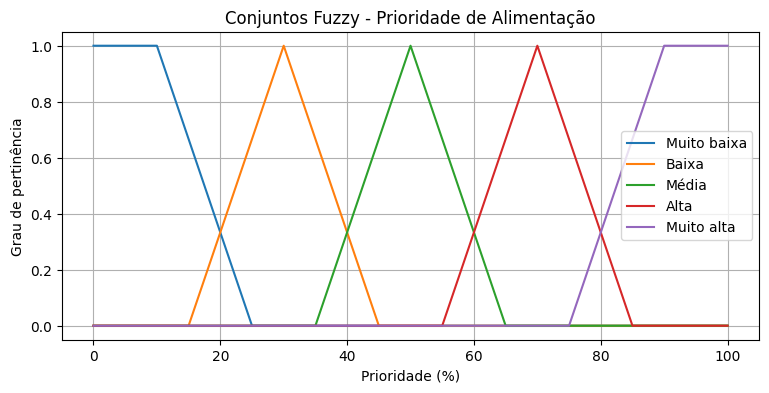

In [5]:
def triangular(x, a, b, c):
    return np.maximum(0, np.minimum((x - a) / (b - a), (c - x) / (c - b)))

def trapezoidal(x, a, b, c, d):
    y = np.zeros_like(x, dtype=float)

    # Left side (rising edge or start plateau)
    if b == a:
        left_side = (x >= a).astype(float)
    else:
        left_side = np.clip((x - a) / (b - a), 0.0, 1.0)

    # Right side (falling edge or end plateau)
    if c == d:
        right_side = (x <= d).astype(float)
    else:
        right_side = np.clip((d - x) / (d - c), 0.0, 1.0)

    y = np.minimum(left_side, right_side)

    return np.clip(y, 0.0, 1.0)

prioridade = np.linspace(0, 100, 101)

prior_muito_baixa = trapezoidal(prioridade, 0, 0, 10, 25)
prior_baixa = triangular(prioridade, 15, 30, 45)
prior_media = triangular(prioridade, 35, 50, 65)
prior_alta = triangular(prioridade, 55, 70, 85)
prior_muito_alta = trapezoidal(prioridade, 75, 90, 100, 100)

plt.figure(figsize=(9,4))
plt.plot(prioridade, prior_muito_baixa, label='Muito baixa')
plt.plot(prioridade, prior_baixa, label='Baixa')
plt.plot(prioridade, prior_media, label='Média')
plt.plot(prioridade, prior_alta, label='Alta')
plt.plot(prioridade, prior_muito_alta, label='Muito alta')
plt.title('Conjuntos Fuzzy - Prioridade de Alimentação')
plt.xlabel('Prioridade (%)')
plt.ylabel('Grau de pertinência')
plt.grid(True)
plt.legend()
plt.show()

In [6]:
def sistema_fuzzy_cargas(criticidade, potencia, urgencia, disponibilidade):

    # criticidade
    c_baixa = trapezoidal(criticidade, 0, 0, 20, 40)
    c_media = triangular(criticidade, 30, 50, 70)
    c_alta = trapezoidal(criticidade, 60, 80, 100, 100)

    # potência da carga
    p_baixa = trapezoidal(potencia, 0, 0, 20, 40)
    p_media = triangular(potencia, 30, 50, 70)
    p_alta = trapezoidal(potencia, 60, 80, 100, 100)

    # urgência
    u_baixa = trapezoidal(urgencia, 0, 0, 20, 40)
    u_media = triangular(urgencia, 30, 50, 70)
    u_alta = trapezoidal(urgencia, 60, 80, 100, 100)

    # disponibilidade do gerador
    d_baixa = trapezoidal(disponibilidade, 0, 0, 25, 45)
    d_media = triangular(disponibilidade, 35, 55, 75)
    d_alta = trapezoidal(disponibilidade, 65, 85, 100, 100)

    # regras fuzzy
    r1 = min(c_alta, u_alta, p_baixa)        # prioridade muito alta
    r2 = min(c_alta, u_alta, p_media)        # prioridade muito alta
    r3 = min(c_alta, u_media)                # prioridade alta
    r4 = min(c_media, u_alta, p_baixa)       # prioridade alta
    r5 = min(c_media, u_media)               # prioridade média
    r6 = min(c_baixa, p_alta)                # prioridade muito baixa
    r7 = min(c_baixa, u_baixa)               # prioridade baixa
    r8 = min(c_alta, d_baixa, p_alta)        # prioridade média
    r9 = min(c_media, d_alta)                # prioridade alta
    r10 = min(c_baixa, d_alta, p_baixa)      # prioridade média

    saida = np.maximum.reduce([
        np.minimum(r1, prior_muito_alta),
        np.minimum(r2, prior_muito_alta),
        np.minimum(r3, prior_alta),
        np.minimum(r4, prior_alta),
        np.minimum(r5, prior_media),
        np.minimum(r6, prior_muito_baixa),
        np.minimum(r7, prior_baixa),
        np.minimum(r8, prior_media),
        np.minimum(r9, prior_alta),
        np.minimum(r10, prior_media)
    ])

    if np.sum(saida) == 0:
        resultado = 0
    else:
        resultado = np.sum(prioridade * saida) / np.sum(saida)

    return resultado

In [7]:
def triangular(x, a, b, c):
    x = np.asarray(x)
    return np.maximum(0, np.minimum((x - a) / (b - a), (c - x) / (c - b)))

def trapezoidal(x, a, b, c, d):
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    # Left side (rising edge or start plateau)
    if b == a:
        left_side = (x >= a).astype(float)
    else:
        left_side = np.clip((x - a) / (b - a), 0.0, 1.0)

    # Right side (falling edge or end plateau)
    if c == d:
        right_side = (x <= d).astype(float)
    else:
        right_side = np.clip((d - x) / (d - c), 0.0, 1.0)

    y = np.minimum(left_side, right_side)

    return np.clip(y, 0.0, 1.0)

def sistema_fuzzy_cargas(criticidade, potencia, urgencia, disponibilidade):

    # criticidade
    c_baixa = trapezoidal(criticidade, 0, 0, 20, 40)
    c_media = triangular(criticidade, 30, 50, 70)
    c_alta = trapezoidal(criticidade, 60, 80, 100, 100)

    # potência da carga
    p_baixa = trapezoidal(potencia, 0, 0, 20, 40)
    p_media = triangular(potencia, 30, 50, 70)
    p_alta = trapezoidal(potencia, 60, 80, 100, 100)

    # urgência
    u_baixa = trapezoidal(urgencia, 0, 0, 20, 40)
    u_media = triangular(urgencia, 30, 50, 70)
    u_alta = trapezoidal(urgencia, 60, 80, 100, 100)

    # disponibilidade do gerador
    d_baixa = trapezoidal(disponibilidade, 0, 0, 25, 45)
    d_media = triangular(disponibilidade, 35, 55, 75)
    d_alta = trapezoidal(disponibilidade, 65, 85, 100, 100)

    # regras fuzzy
    r1 = min(c_alta, u_alta, p_baixa)        # prioridade muito alta
    r2 = min(c_alta, u_alta, p_media)        # prioridade muito alta
    r3 = min(c_alta, u_media)                # prioridade alta
    r4 = min(c_media, u_alta, p_baixa)       # prioridade alta
    r5 = min(c_media, u_media)               # prioridade média
    r6 = min(c_baixa, p_alta)                # prioridade muito baixa
    r7 = min(c_baixa, u_baixa)               # prioridade baixa
    r8 = min(c_alta, d_baixa, p_alta)        # prioridade média
    r9 = min(c_media, d_alta)                # prioridade alta
    r10 = min(c_baixa, d_alta, p_baixa)      # prioridade média

    saida = np.maximum.reduce([
        np.minimum(r1, prior_muito_alta),
        np.minimum(r2, prior_muito_alta),
        np.minimum(r3, prior_alta),
        np.minimum(r4, prior_alta),
        np.minimum(r5, prior_media),
        np.minimum(r6, prior_muito_baixa),
        np.minimum(r7, prior_baixa),
        np.minimum(r8, prior_media),
        np.minimum(r9, prior_alta),
        np.minimum(r10, prior_media)
    ])

    if np.sum(saida) == 0:
        resultado = 0
    else:
        resultado = np.sum(prioridade * saida) / np.sum(saida)

    return resultado

df['prioridade_fuzzy'] = df.apply(
    lambda row: sistema_fuzzy_cargas(
        row['criticidade_norm'],
        row['potencia_norm'],
        row['urgencia_norm'],
        energia_disponivel_percentual
    ),
    axis=1
)

df_resultado = df.sort_values(by='prioridade_fuzzy', ascending=False)
df_resultado

,carga,potencia_kw,criticidade,tempo_toleravel_min,potencia_norm,criticidade_norm,urgencia_norm,prioridade_fuzzy
3,Iluminação de Emergência,2,8,5,11.111111,80.0,91.666667,90.981481
2,CLP Linha de Produção,4,9,2,22.222222,90.0,96.666667,90.693227
0,Data Center,8,10,1,44.444444,100.0,98.333333,90.218391
1,Sistema de Incêndio,5,10,1,27.777778,100.0,98.333333,89.878261
4,Bomba de Refrigeração,12,8,3,66.666667,80.0,95.000000,68.003876
8,Iluminação Comum,4,4,20,22.222222,40.0,66.666667,63.228571
9,Máquina Auxiliar,15,5,25,83.333333,50.0,58.333333,50.000000
7,Tomadas Administrativas,6,2,60,33.333333,20.0,0.000000,30.000000
5,Compressor Industrial,18,6,15,100.000000,60.0,75.000000,0.000000
6,Ar-condicionado Administrativo,10,3,30,55.555556,30.0,50.000000,0.000000


In [8]:
potencia_acumulada = 0
decisoes = []

for _, row in df_resultado.iterrows():
    if potencia_acumulada + row['potencia_kw'] <= potencia_gerador_kw:
        decisoes.append('MANTER LIGADA')
        potencia_acumulada += row['potencia_kw']
    else:
        decisoes.append('DESLIGAR / NÃO ALIMENTAR')

df_resultado['decisao'] = decisoes

df_resultado[['carga', 'potencia_kw', 'criticidade', 'tempo_toleravel_min', 'prioridade_fuzzy', 'decisao']]

,carga,potencia_kw,criticidade,tempo_toleravel_min,prioridade_fuzzy,decisao
3,Iluminação de Emergência,2,8,5,90.981481,MANTER LIGADA
2,CLP Linha de Produção,4,9,2,90.693227,MANTER LIGADA
0,Data Center,8,10,1,90.218391,MANTER LIGADA
1,Sistema de Incêndio,5,10,1,89.878261,MANTER LIGADA
4,Bomba de Refrigeração,12,8,3,68.003876,MANTER LIGADA
8,Iluminação Comum,4,4,20,63.228571,MANTER LIGADA
9,Máquina Auxiliar,15,5,25,50.000000,DESLIGAR / NÃO ALIMENTAR
7,Tomadas Administrativas,6,2,60,30.000000,DESLIGAR / NÃO ALIMENTAR
5,Compressor Industrial,18,6,15,0.000000,DESLIGAR / NÃO ALIMENTAR
6,Ar-condicionado Administrativo,10,3,30,0.000000,DESLIGAR / NÃO ALIMENTAR


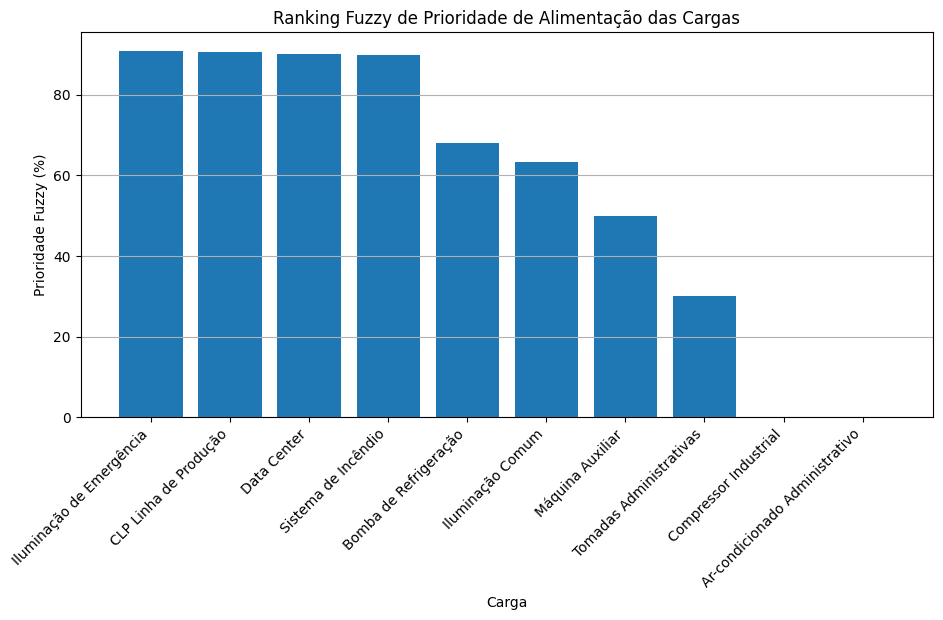

In [9]:
plt.figure(figsize=(11,5))
plt.bar(df_resultado['carga'], df_resultado['prioridade_fuzzy'])
plt.title('Ranking Fuzzy de Prioridade de Alimentação das Cargas')
plt.xlabel('Carga')
plt.ylabel('Prioridade Fuzzy (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [10]:
print("RESUMO OPERACIONAL DO SISTEMA DE EMERGÊNCIA")
print("-" * 55)
print(f"Potência disponível no gerador: {potencia_gerador_kw:.2f} kW")
print(f"Potência total das cargas: {potencia_total_kw:.2f} kW")
print(f"Potência alimentada: {potencia_acumulada:.2f} kW")
print(f"Margem disponível: {potencia_gerador_kw - potencia_acumulada:.2f} kW")
print("-" * 55)

for _, row in df_resultado.iterrows():
    print(f"{row['carga']}: {row['decisao']} | Prioridade: {row['prioridade_fuzzy']:.2f}% | Potência: {row['potencia_kw']} kW")

RESUMO OPERACIONAL DO SISTEMA DE EMERGÊNCIA
-------------------------------------------------------
Potência disponível no gerador: 35.00 kW
Potência total das cargas: 84.00 kW
Potência alimentada: 35.00 kW
Margem disponível: 0.00 kW
-------------------------------------------------------
Iluminação de Emergência: MANTER LIGADA | Prioridade: 90.98% | Potência: 2 kW
CLP Linha de Produção: MANTER LIGADA | Prioridade: 90.69% | Potência: 4 kW
Data Center: MANTER LIGADA | Prioridade: 90.22% | Potência: 8 kW
Sistema de Incêndio: MANTER LIGADA | Prioridade: 89.88% | Potência: 5 kW
Bomba de Refrigeração: MANTER LIGADA | Prioridade: 68.00% | Potência: 12 kW
Iluminação Comum: MANTER LIGADA | Prioridade: 63.23% | Potência: 4 kW
Máquina Auxiliar: DESLIGAR / NÃO ALIMENTAR | Prioridade: 50.00% | Potência: 15 kW
Tomadas Administrativas: DESLIGAR / NÃO ALIMENTAR | Prioridade: 30.00% | Potência: 6 kW
Compressor Industrial: DESLIGAR / NÃO ALIMENTAR | Prioridade: 0.00% | Potência: 18 kW
Ar-condicionado A

In [11]:
df_resultado['criterio_manual'] = df_resultado['criticidade']

df_comparacao = df_resultado.sort_values(by='criterio_manual', ascending=False)

display(df_comparacao[['carga', 'criticidade', 'prioridade_fuzzy', 'decisao']])

,carga,criticidade,prioridade_fuzzy,decisao
1,Sistema de Incêndio,10,89.878261,MANTER LIGADA
0,Data Center,10,90.218391,MANTER LIGADA
2,CLP Linha de Produção,9,90.693227,MANTER LIGADA
3,Iluminação de Emergência,8,90.981481,MANTER LIGADA
4,Bomba de Refrigeração,8,68.003876,MANTER LIGADA
5,Compressor Industrial,6,0.000000,DESLIGAR / NÃO ALIMENTAR
9,Máquina Auxiliar,5,50.000000,DESLIGAR / NÃO ALIMENTAR
8,Iluminação Comum,4,63.228571,MANTER LIGADA
6,Ar-condicionado Administrativo,3,0.000000,DESLIGAR / NÃO ALIMENTAR
7,Tomadas Administrativas,2,30.000000,DESLIGAR / NÃO ALIMENTAR


In [12]:
geradores = [20, 30, 40, 50, 60]
resumo = []

for gerador in geradores:
    disponibilidade = 100 * gerador / potencia_total_kw

    temp = df.copy()
    temp['prioridade_fuzzy'] = temp.apply(
        lambda row: sistema_fuzzy_cargas(
            row['criticidade_norm'],
            row['potencia_norm'],
            row['urgencia_norm'],
            disponibilidade
        ),
        axis=1
    )

    temp = temp.sort_values(by='prioridade_fuzzy', ascending=False)

    potencia_usada = 0
    cargas_ligadas = 0

    for _, row in temp.iterrows():
        if potencia_usada + row['potencia_kw'] <= gerador:
            potencia_usada += row['potencia_kw']
            cargas_ligadas += 1

    resumo.append([gerador, potencia_usada, cargas_ligadas])

df_resumo = pd.DataFrame(resumo, columns=['Gerador kW', 'Potência Alimentada kW', 'Número de Cargas Ligadas'])
df_resumo

,Gerador kW,Potência Alimentada kW,Número de Cargas Ligadas
0,20,19,4
1,30,29,6
2,40,35,6
3,50,50,7
4,60,59,8


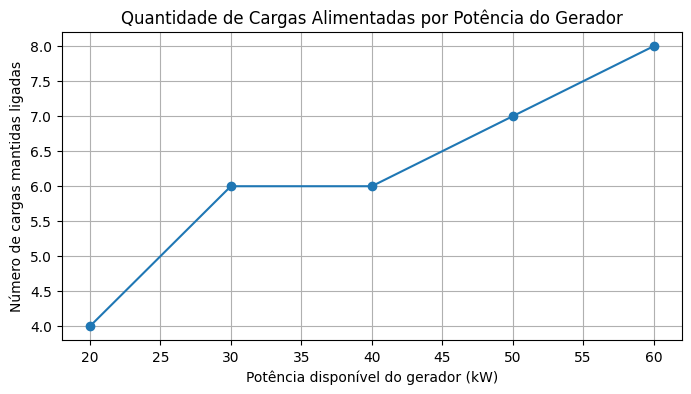

In [13]:
plt.figure(figsize=(8,4))
plt.plot(df_resumo['Gerador kW'], df_resumo['Número de Cargas Ligadas'], marker='o')
plt.title('Quantidade de Cargas Alimentadas por Potência do Gerador')
plt.xlabel('Potência disponível do gerador (kW)')
plt.ylabel('Número de cargas mantidas ligadas')
plt.grid(True)
plt.show()

In [14]:
regras = pd.DataFrame({
    'Regra': [
        'R1', 'R2', 'R3', 'R4', 'R5',
        'R6', 'R7', 'R8', 'R9', 'R10'
    ],
    'Condição': [
        'Criticidade alta + urgência alta + potência baixa',
        'Criticidade alta + urgência alta + potência média',
        'Criticidade alta + urgência média',
        'Criticidade média + urgência alta + potência baixa',
        'Criticidade média + urgência média',
        'Criticidade baixa + potência alta',
        'Criticidade baixa + urgência baixa',
        'Criticidade alta + disponibilidade baixa + potência alta',
        'Criticidade média + disponibilidade alta',
        'Criticidade baixa + disponibilidade alta + potência baixa'
    ],
    'Saída': [
        'Prioridade muito alta',
        'Prioridade muito alta',
        'Prioridade alta',
        'Prioridade alta',
        'Prioridade média',
        'Prioridade muito baixa',
        'Prioridade baixa',
        'Prioridade média',
        'Prioridade alta',
        'Prioridade média'
    ]
})

display(regras)

,Regra,Condição,Saída
0,R1,Criticidade alta + urgência alta + potência baixa,Prioridade muito alta
1,R2,Criticidade alta + urgência alta + potência média,Prioridade muito alta
2,R3,Criticidade alta + urgência média,Prioridade alta
3,R4,Criticidade média + urgência alta + potência b...,Prioridade alta
4,R5,Criticidade média + urgência média,Prioridade média
5,R6,Criticidade baixa + potência alta,Prioridade muito baixa
6,R7,Criticidade baixa + urgência baixa,Prioridade baixa
7,R8,Criticidade alta + disponibilidade baixa + pot...,Prioridade média
8,R9,Criticidade média + disponibilidade alta,Prioridade alta
9,R10,Criticidade baixa + disponibilidade alta + pot...,Prioridade média


In [15]:
df_resultado.to_csv('resultado_cargas_prioritarias.csv', index=False)

print("Arquivo resultado_cargas_prioritarias.csv salvo com sucesso!")

Arquivo resultado_cargas_prioritarias.csv salvo com sucesso!


In [16]:
eficiencia = potencia_acumulada / potencia_gerador_kw * 100

print(f"Potência utilizada: {potencia_acumulada:.2f} kW")
print(f"Potência disponível: {potencia_gerador_kw:.2f} kW")
print(f"Reserva operacional: {potencia_gerador_kw-potencia_acumulada:.2f} kW")
print(f"Eficiência de utilização: {eficiencia:.2f}%")

Potência utilizada: 35.00 kW
Potência disponível: 35.00 kW
Reserva operacional: 0.00 kW
Eficiência de utilização: 100.00%


In [17]:
print("=" * 60)
print(" SISTEMA INTELIGENTE DE GERENCIAMENTO DE ENERGIA")
print("      Lógica Fuzzy para Alimentação Emergencial")
print("=" * 60)

potencia_gerador_kw = float(input("\nDigite a potência disponível do gerador (kW): "))

potencia_total_kw = df['potencia_kw'].sum()

energia_disponivel_percentual = (potencia_gerador_kw / potencia_total_kw) * 100

print("\nResumo do Sistema")
print("-" * 60)
print(f"Potência total instalada : {potencia_total_kw:.2f} kW")
print(f"Potência do gerador      : {potencia_gerador_kw:.2f} kW")
print(f"Disponibilidade energética: {energia_disponivel_percentual:.2f}%")
print("-" * 60)

 SISTEMA INTELIGENTE DE GERENCIAMENTO DE ENERGIA
      Lógica Fuzzy para Alimentação Emergencial

Digite a potência disponível do gerador (kW): 33

Resumo do Sistema
------------------------------------------------------------
Potência total instalada : 84.00 kW
Potência do gerador      : 33.00 kW
Disponibilidade energética: 39.29%
------------------------------------------------------------


In [18]:
print("\n" + "=" * 60)
print(" RESULTADO DO GERENCIAMENTO DE ENERGIA")
print("=" * 60)

print(f"Potência disponível : {potencia_gerador_kw:.2f} kW")
print(f"Potência utilizada  : {potencia_acumulada:.2f} kW")
print(f"Reserva operacional : {potencia_gerador_kw - potencia_acumulada:.2f} kW")
print(f"Eficiência          : {(potencia_acumulada/potencia_gerador_kw)*100:.2f}%")

print("\nCARGAS MANTIDAS")
print("-" * 60)

for _, row in df_resultado.iterrows():
    if row['decisao'] == 'MANTER LIGADA':
        print(f"✔ {row['carga']} ({row['potencia_kw']} kW)")

print("\nCARGAS DESLIGADAS")
print("-" * 60)

for _, row in df_resultado.iterrows():
    if row['decisao'] != 'MANTER LIGADA':
        print(f"✖ {row['carga']} ({row['potencia_kw']} kW)")


 RESULTADO DO GERENCIAMENTO DE ENERGIA
Potência disponível : 33.00 kW
Potência utilizada  : 35.00 kW
Reserva operacional : -2.00 kW
Eficiência          : 106.06%

CARGAS MANTIDAS
------------------------------------------------------------
✔ Iluminação de Emergência (2 kW)
✔ CLP Linha de Produção (4 kW)
✔ Data Center (8 kW)
✔ Sistema de Incêndio (5 kW)
✔ Bomba de Refrigeração (12 kW)
✔ Iluminação Comum (4 kW)

CARGAS DESLIGADAS
------------------------------------------------------------
✖ Máquina Auxiliar (15 kW)
✖ Tomadas Administrativas (6 kW)
✖ Compressor Industrial (18 kW)
✖ Ar-condicionado Administrativo (10 kW)
